Código 1. Maclaurin_e

In [1]:
import numpy as np
from math import factorial, e

factorize = np.vectorize(factorial)

def e_x(x, terms=10):
    n = np.arange(terms)
    return np.sum(x**n / factorize(n))

if __name__ == "__main__":
    print("N (terms)\tMaclaurin\t\tError")

    for n in range(1, 14):
        maclaurin = e_x(2, terms=n)
        error = abs(e**2 - maclaurin)

        print(f"{n}\t\t{maclaurin:.8f}\t\t{error:.8f}")

N (terms)	Maclaurin		Error
1		1.00000000		6.38905610
2		3.00000000		4.38905610
3		5.00000000		2.38905610
4		6.33333333		1.05572277
5		7.00000000		0.38905610
6		7.26666667		0.12238943
7		7.35555556		0.03350054
8		7.38095238		0.00810372
9		7.38730159		0.00175451
10		7.38871252		0.00034358
11		7.38899471		0.00006139
12		7.38904602		0.00001008
13		7.38905457		0.00000153


Código 2. Maclaurin_pi

In [2]:
import math

def approximate_pi(tol=1e-6):
    pi_approx = 0
    n = 0
    term = 1

    while abs(term) > tol:
        term = (-1)**n / (2*n + 1)
        pi_approx += term
        n += 1

    pi_approx *= 4
    return pi_approx, n


if __name__ == "__main__":
    
    tolerance = 1e-6
    
    pi_approx, iterations = approximate_pi(tolerance)

    print("Approximated pi:", pi_approx)
    print("Actual pi:", math.pi)
    print("Error:", abs(math.pi - pi_approx))
    print("Iterations required:", iterations)

Approximated pi: 3.1415946535856922
Actual pi: 3.141592653589793
Error: 1.999995899115703e-06
Iterations required: 500001


Código 3. Leibniz_pi

In [3]:
import math

def approximate_pi_maclaurin(sig_digits=7):
    
    pi_real = math.pi
    pi_approx = 0
    n = 0
    
    tolerance = 0.5 * 10**(-sig_digits)

    while abs(pi_real - 4*pi_approx) > tolerance:
        
        term = (-1)**n / (2*n + 1)
        pi_approx += term
        n += 1

    pi_approx = 4 * pi_approx

    return pi_approx, n


if __name__ == "__main__":

    digits = 7   # número de cifras significativas deseadas
    
    pi_value, iterations = approximate_pi_maclaurin(digits)

    print("Desired significant digits:", digits)
    print("Approximated pi:", pi_value)
    print("Actual value of pi:", math.pi)
    print("Error:", abs(math.pi - pi_value))
    print("Iterations required:", iterations)

Desired significant digits: 7
Approximated pi: 3.1415926035897974
Actual value of pi: 3.141592653589793
Error: 4.999999569932356e-08
Iterations required: 19999992


Código 4. Bracketing Bungee

In [4]:
import numpy as np

# Datos
cd = 0.25  
g = 9.81    
v = 36      
t = 4       
# Function
def f_m(m):
    return np.sqrt(g*m/cd) * np.tanh(np.sqrt(g*cd/m)*t) - v
# Incremental search
def incsearch(func, xmin, xmax, ns=100000):

    x = np.linspace(xmin, xmax, ns)
    f = func(x)

    brackets = []

    for k in range(len(x)-1):
        if np.sign(f[k]) != np.sign(f[k+1]):
            brackets.append((x[k], x[k+1]))

    if len(brackets) == 0:
        print("No brackets found")
        print("Try increasing ns or changing interval")
    else:
        print("Number of brackets:", len(brackets))
        print("Intervals [Lower, Upper]:")
        for b in brackets:
            print(f"({float(b[0]):.6f}, {float(b[1]):.6f})")

    return brackets

# Main program
if __name__ == "__main__":

    xmin = 50
    xmax = 200

    print("Bungee Bracketing Problem")

    intervals = incsearch(f_m, xmin, xmax)

Bungee Bracketing Problem
Number of brackets: 1
Intervals [Lower, Upper]:
(142.736927, 142.738427)


Código 5. SinCos_Bracketing

In [5]:
import numpy as np
# Function
def f(x):
    return np.sin(10*x) + np.cos(3*x)
# Bracketing (Incremental Search)
def bracketing(func, a, b, n=200):
    x = np.linspace(a, b, n)
    brackets = []

    for i in range(len(x)-1):

        if func(x[i]) * func(x[i+1]) < 0:
            brackets.append((x[i], x[i+1]))

    return brackets

if __name__ == "__main__":

    a = 3
    b = 6

    intervals = bracketing(f, a, b, 200)

    print("Intervals containing roots:\n")

    for i, interval in enumerate(intervals, 1):
        print(f"Root {i}: ({interval[0]:.6f}, {interval[1]:.6f})")

    print("\nTotal roots detected:", len(intervals))

Intervals containing roots:

Root 1: (3.256281, 3.271357)
Root 2: (3.361809, 3.376884)
Root 3: (3.738693, 3.753769)
Root 4: (4.221106, 4.236181)
Root 5: (4.251256, 4.266332)
Root 6: (4.703518, 4.718593)
Root 7: (5.155779, 5.170854)
Root 8: (5.185930, 5.201005)
Root 9: (5.668342, 5.683417)

Total roots detected: 9


Código 6. Bungee Bisección

In [6]:
import numpy as np
# Función
# f(x) = sin(10x) + cos(3x)
def f(x):
    return np.sin(10*x) + np.cos(3*x)
# BRACKETING
def bracketing(func, a, b, n=1000):

    x = np.linspace(a, b, n)
    fx = func(x)

    intervals = []

    for i in range(len(x)-1):
        if np.sign(fx[i]) != np.sign(fx[i+1]):
            intervals.append((x[i], x[i+1]))

    return intervals
# BISECCIÓN
def bisection(func, xl, xu, es=1e-6, maxit=100):

    xr = xl
    iter = 0
    ea = 100

    while True:

        xrold = xr
        xr = (xl + xu) / 2
        iter += 1

        if xr != 0:
            ea = abs((xr - xrold)/xr) * 100

        test = func(xl) * func(xr)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or iter >= maxit:
            break

    return xr, ea, iter

# PROGRAMA PRINCIPAL


print("ROOTS OF f(x) = sin(10x) + cos(3x)")

a = 3
b = 6

#Bracketing
intervals = bracketing(f, a, b)

print("\nFound intervals:")
for i, inter in enumerate(intervals):
    print(f"Intervalo {i+1}: ({inter[0]:.6f}, {inter[1]:.6f})")

#Bisección en cada intervalo
print("\nFound roots:\n")

for i, inter in enumerate(intervals):

    root, ea, it = bisection(f, inter[0], inter[1])

    print(f"Root {i+1}:")
    print(f"x = {root:.10f}")
    print(f"relative error = {ea:.8f} %")
    print(f"iterations = {it}")
    print()

ROOTS OF f(x) = sin(10x) + cos(3x)

Found intervals:
Intervalo 1: (3.261261, 3.264264)
Intervalo 2: (3.363363, 3.366366)
Intervalo 3: (3.744745, 3.747748)
Intervalo 4: (4.228228, 4.231231)
Intervalo 5: (4.261261, 4.264264)
Intervalo 6: (4.711712, 4.714715)
Intervalo 7: (5.159159, 5.162162)
Intervalo 8: (5.195195, 5.198198)
Intervalo 9: (5.678679, 5.681682)

Found roots:

Root 1:
x = 3.2624231516
relative error = 0.00000070 %
iterations = 17

Root 2:
x = 3.3659921136
relative error = 0.00000068 %
iterations = 17

Root 3:
x = 3.7457450660
relative error = 0.00000061 %
iterations = 17

Root 4:
x = 4.2290670263
relative error = 0.00000054 %
iterations = 17

Root 5:
x = 4.2635900137
relative error = 0.00000054 %
iterations = 17

Root 6:
x = 4.7123890095
relative error = 0.00000097 %
iterations = 16

Root 7:
x = 5.1611879366
relative error = 0.00000089 %
iterations = 16

Root 8:
x = 5.1957109239
relative error = 0.00000088 %
iterations = 16

Root 9:
x = 5.6790328384
relative error = 0.000000

Código 7. SinCos_Bissección

In [7]:
import numpy as np
# Función, f(x) = sin(10x) + cos(3x)
def f(x):
    return np.sin(10*x) + np.cos(3*x)
# BRACKETING
def bracketing(func, a, b, n=1000):

    x = np.linspace(a, b, n)
    fx = func(x)

    intervals = []

    for i in range(len(x)-1):
        if np.sign(fx[i]) != np.sign(fx[i+1]):
            intervals.append((x[i], x[i+1]))

    return intervals
# BISECCIÓN
def bisection(func, xl, xu, es=1e-6, maxit=100):

    xr = xl
    iter = 0
    ea = 100

    while True:

        xrold = xr
        xr = (xl + xu) / 2
        iter += 1

        if xr != 0:
            ea = abs((xr - xrold)/xr) * 100

        test = func(xl) * func(xr)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or iter >= maxit:
            break

    return xr, ea, iter

print("ROOTS OF f(x) = sin(10x) + cos(3x)")

a = 3
b = 6

#Bracketing
intervals = bracketing(f, a, b)

print("\nFound intervals:")
for i, inter in enumerate(intervals):
    print(f"Intervalo {i+1}: ({inter[0]:.6f}, {inter[1]:.6f})")

#Bisección en cada intervalo
print("\nFound roots:\n")

for i, inter in enumerate(intervals):

    root, ea, it = bisection(f, inter[0], inter[1])

    print(f"Root {i+1}:")
    print(f"x = {root:.10f}")
    print(f"relative error = {ea:.8f} %")
    print(f"iterations = {it}")
    print()

ROOTS OF f(x) = sin(10x) + cos(3x)

Found intervals:
Intervalo 1: (3.261261, 3.264264)
Intervalo 2: (3.363363, 3.366366)
Intervalo 3: (3.744745, 3.747748)
Intervalo 4: (4.228228, 4.231231)
Intervalo 5: (4.261261, 4.264264)
Intervalo 6: (4.711712, 4.714715)
Intervalo 7: (5.159159, 5.162162)
Intervalo 8: (5.195195, 5.198198)
Intervalo 9: (5.678679, 5.681682)

Found roots:

Root 1:
x = 3.2624231516
relative error = 0.00000070 %
iterations = 17

Root 2:
x = 3.3659921136
relative error = 0.00000068 %
iterations = 17

Root 3:
x = 3.7457450660
relative error = 0.00000061 %
iterations = 17

Root 4:
x = 4.2290670263
relative error = 0.00000054 %
iterations = 17

Root 5:
x = 4.2635900137
relative error = 0.00000054 %
iterations = 17

Root 6:
x = 4.7123890095
relative error = 0.00000097 %
iterations = 16

Root 7:
x = 5.1611879366
relative error = 0.00000089 %
iterations = 16

Root 8:
x = 5.1957109239
relative error = 0.00000088 %
iterations = 16

Root 9:
x = 5.6790328384
relative error = 0.000000

Código 8. Funcion f(x) = x**10 - 1, raiz biseccion

In [ ]:
import numpy as np

# Function f(x) = x^10 - 1
def f(x):
    return x**10 - 1


# Bisection method
def bisection(func, xl, xu, es=1e-6, maxit=100):

    # Check if there is a sign change
    if func(xl) * func(xu) > 0:
        print("No sign change in the interval")
        return None

    xr = xl
    ea = 100
    iterations = 0

    while True:

        xrold = xr
        xr = (xl + xu) / 2
        iterations += 1

        if xr != 0:
            ea = abs((xr - xrold) / xr) * 100

        test = func(xl) * func(xr)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or iterations >= maxit:
            break

    return xr, ea, iterations

xl = 0
xu = 1.5

root, error, it = bisection(f, xl, xu)

print(f"Initial interval: [{xl}, {xu}]")
print(f"Root = {root:.10f}")
print(f"Relative error = {error:.6f}%")
print(f"Iterations = {it}")

Initial interval: [0, 1.5]
Root = 1.0000000019
Relative error = 0.000001%
Iterations = 28


Código 9. Función f(x) = x**10 - 1, raiz, método falsa posición

In [ ]:
import numpy as np

def f(x):
    return x**10 - 1


def false_position(func, xl, xu, es=1e-6, maxit=60):

    if func(xl) * func(xu) > 0:
        print("No sign change in the interval")
        return None

    xr = xl
    ea = 100
    it = 0

    print("iter    xl        xu        xr        error")

    while True:

        xrold = xr
        xr = xu - func(xu)*(xl - xu)/(func(xl) - func(xu))
        it += 1

        if xr != 0:
            ea = abs((xr - xrold)/xr) * 100

        print(f"{it:3d}   {xl:.6f}   {xu:.6f}   {xr:.6f}   {ea:.6f}")

        test = func(xl) * func(xr)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or it >= maxit:
            break

    return xr, ea, it


xl = 0
xu = 1.5

root, error, iterations = false_position(f, xl, xu)

print("\nFinal Result")
print(f"Root = {root:.10f}")
print(f"Relative error = {error:.6f}%")
print(f"Iterations = {iterations}")

iter    xl        xu        xr        error
  1   0.000000   1.500000   0.026012   100.000000
  2   0.026012   1.500000   0.051573   49.562670
  3   0.051573   1.500000   0.076691   32.751941
  4   0.076691   1.500000   0.101374   24.347863
  5   0.101374   1.500000   0.125628   19.306445
  6   0.125628   1.500000   0.149462   15.946356
  7   0.149462   1.500000   0.172882   13.547027
  8   0.172882   1.500000   0.195896   11.748172
  9   0.195896   1.500000   0.218512   10.349633
 10   0.218512   1.500000   0.240735   9.231314
 11   0.240735   1.500000   0.262572   8.316790
 12   0.262572   1.500000   0.284031   7.555112
 13   0.284031   1.500000   0.305118   6.911003
 14   0.305118   1.500000   0.325839   6.359266
 15   0.325839   1.500000   0.346200   5.881420
 16   0.346200   1.500000   0.366208   5.463603
 17   0.366208   1.500000   0.385869   5.095210
 18   0.385869   1.500000   0.405188   4.767989
 19   0.405188   1.500000   0.424172   4.475421
 20   0.424172   1.500000   0.4428

Código 10. Graficación y Solución del valor del pH en la ecuación de gases invernaderos.

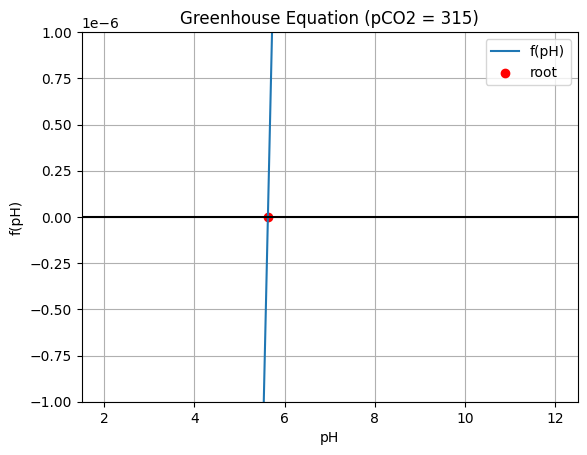

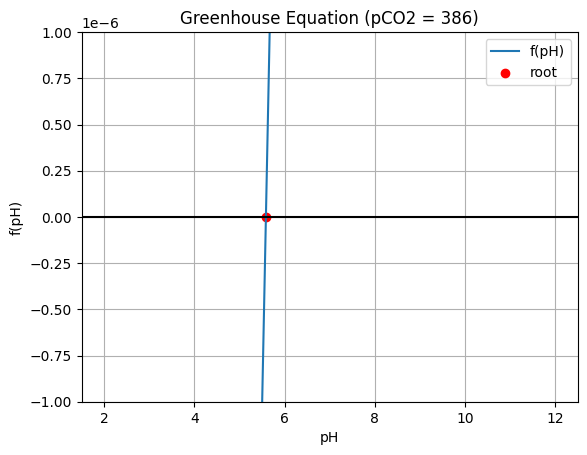

1958 (pCO2 = 315)
Bisection: (5.630448401963804, 1.6150474614086679e-15, 5.169007577901395e-09, 35)
False Position: (2.485807314852339, -0.003267325949882045, 0.23106684205932262, 50)

2008 (pCO2 = 386)
Bisection: (5.586382870853413, 3.292573343556234e-15, 5.20978084201515e-09, 35)
False Position: (2.429213152715592, -0.0037220879991868364, 0.22100550827888593, 50)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fpH(pH, pCO2):
    K1 = 10**(-6.3)
    K2 = 10**(-10.3)
    Kw = 10**(-14)
    KH = 10**(-1.46)

    H = 10**(-pH)

    f = K1/(1e6*H)*KH*pCO2 + 2*K2*K1/(1e6*H)*KH*pCO2 + Kw/H - H
    return f


def bisection(func, xl, xu, pCO2, es=1e-8, maxit=50):
    xr = xl
    ea = 100
    it = 0

    while True:
        xrold = xr
        xr = (xl + xu)/2
        it += 1

        if xr != 0:
            ea = abs((xr - xrold)/xr)*100

        test = func(xl,pCO2) * func(xr,pCO2)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or it >= maxit:
            break

    return xr, func(xr,pCO2), ea, it


def false_position(func, xl, xu, pCO2, es=1e-8, maxit=50):
    xr = xl
    ea = 100
    it = 0

    while True:
        xrold = xr

        xr = xu - func(xu,pCO2)*(xl-xu)/(func(xl,pCO2)-func(xu,pCO2))
        it += 1

        if xr != 0:
            ea = abs((xr - xrold)/xr)*100

        test = func(xl,pCO2) * func(xr,pCO2)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
        else:
            ea = 0

        if ea <= es or it >= maxit:
            break

    return xr, func(xr,pCO2), ea, it


pH = np.linspace(2,12,500)


# 1958 graphic

root1958 = bisection(fpH,2,12,315)[0]

plt.figure()
plt.plot(pH, fpH(pH,315), label="f(pH)")
plt.axhline(0,color='black')
plt.scatter(root1958,0,color='red',label="root")

plt.title("Greenhouse Equation (pCO2 = 315)")
plt.xlabel("pH")
plt.ylabel("f(pH)")
plt.ylim(-1e-6,1e-6)
plt.grid()
plt.legend()
plt.show()


# la graph de 2008

root2008 = bisection(fpH,2,12,386)[0]

plt.figure()
plt.plot(pH, fpH(pH,386), label="f(pH)")
plt.axhline(0,color='black')
plt.scatter(root2008,0,color='red',label="root")

plt.title("Greenhouse Equation (pCO2 = 386)")
plt.xlabel("pH")
plt.ylabel("f(pH)")
plt.ylim(-1e-6,1e-6)
plt.grid()
plt.legend()
plt.show()


# roots

pH1958_bis = bisection(fpH,2,12,315)
pH1958_fp = false_position(fpH,2,12,315)

pH2008_bis = bisection(fpH,2,12,386)
pH2008_fp = false_position(fpH,2,12,386)


print("1958 (pCO2 = 315)")
print("Bisection:", pH1958_bis)
print("False Position:", pH1958_fp)

print("\n2008 (pCO2 = 386)")
print("Bisection:", pH2008_bis)
print("False Position:", pH2008_fp)

Código 11. raíz de la función f(x) = x – e**(-x), empleando el método de punto fíjo

In [ ]:
import numpy as np

def fixpt(g, x0, es=1e-6, maxit=50):

    iter = 0
    ea = 100

    while True:

        x1 = g(x0)
        iter += 1

        if x1 != 0:
            ea = abs((x1-x0)/x1)*100

        if ea <= es or iter >= maxit:
            break

        x0 = x1

    return x1, ea, iter


# Primer forma: g(x) = e^(-x)

g1 = lambda x: np.exp(-x)

root1, ea1, iter1 = fixpt(g1, 0)

print("Formulation: g(x) = e^(-x)")
print("Root =", root1)
print("Relative error =", ea1)
print("Iterations =", iter1)


# Forma 2. g(x) = -ln(x)

def g2(x):
    if x <= 0:
        return np.nan
    return -np.log(x)

root2, ea2, iter2 = fixpt(g2, 0.5)

print("\nFormulation: g(x) = -ln(x)")
print("Root =", root2)
print("Relative error =", ea2)
print("Iterations =", iter2)

Formulation: g(x) = e^(-x)
Root = 0.5671432919855762
Relative error = 7.677540341648007e-07
Iterations = 35

Formulation: g(x) = -ln(x)
Root = nan
Relative error = nan
Iterations = 50


Código 12. Raíz de la función f(x) = x – e**(-x), empleando el método de Wegstein

In [ ]:
import math

def wegstein(g, x0, x1, tol=1e-12, max_iter=100):
    for k in range(max_iter):
        g0 = g(x0)
        g1 = g(x1)
        
        # evitar división por cero
        if (g1 - g0 - (x1 - x0)) == 0:
            print("División por cero en Wegstein")
            return x1, k
        q = (g1 - g0) / (x1 - x0)
        
        x2 = (q * x1 - g1) / (q - 1)
        
        if abs(x2 - x1) < tol:
            return x2, k + 1
        
        x0, x1 = x1, x2
    
    return x1, max_iter
# f(x) = x - e^x. 1: g(x) = e^{-x}
g1 = lambda x: math.exp(-x)

# g(x) = -ln(x)
g2 = lambda x: -math.log(x)

# caso 1
root1, it1 = wegstein(g1, 0.0, 0.25)

# case 2
root2, it2 = wegstein(g2, 0.45, 0.5)

print("Formulación g(x)=e^{-x}")
print("Raíz:", root1)
print("Iteraciones:", it1)

print("\nFormulación g(x)=-ln(x)")
print("Raíz:", root2)
print("Iteraciones:", it2)

# referencia
x_real = 0.567143140453502
print("\nValor real:", x_real)

Formulación g(x)=e^{-x}
Raíz: 0.5671432904097838
Iteraciones: 6

Formulación g(x)=-ln(x)
Raíz: 0.5671432904097838
Iteraciones: 6

Valor real: 0.567143140453502


Código 13. Raíz de la función f(x) = e**(-x) - x, empleando el método de Newton-Raphson

In [ ]:
import math

def newton_raphson(f, df, x0, tol=1e-12, max_iter=100):
    xr = x0
    iter_count = 0
    ea = float('inf')
    
    while iter_count < max_iter:
        xrold = xr
        
        # fórmula de Newton
        xr = xr - f(xr)/df(xr)
        
        iter_count += 1
        
        if xr != 0:
            ea = abs((xr - xrold) / xr) * 100
        
        if ea < tol:
            break
    
    return xr, ea, iter_count


# 1
def f(x):
    return math.exp(-x) - x

# 1 derivada
def df(x):
    return -math.exp(-x) - 1

# valor inicial
x0 = 0.0

root, error, it = newton_raphson(f, df, x0)

print("Raíz aproximada:", root)
print("Error relativo (%):", error)
print("Iteraciones:", it)

# ref
x_real = 0.567143140453502
print("\nValor real:", x_real)

Raíz aproximada: 0.567143290409784
Error relativo (%): 5.08968352942999e-13
Iteraciones: 5

Valor real: 0.567143140453502


Código 14. Raíz de la función f(x) =f(x) = x**10 - 1, empleando el método de Newton-Raphson

In [ ]:
import math

def newton_raphson(f, df, x0, tol=1e-12, max_iter=100):
    xr = x0
    iter_count = 0
    ea = float('inf')
    
    print(f"{'Iter':<5} {'x':<20} {'Error (%)':<20}")
    
    while iter_count < max_iter:
        xrold = xr
        
        # fórmula de Newton
        xr = xr - f(xr)/df(xr)
        
        iter_count += 1
        
        if xr != 0:
            ea = abs((xr - xrold)/xr) * 100
        
        print(f"{iter_count:<5} {xr:<20.12f} {ea:<20.12f}")
        
        if ea < tol:
            break
    
    return xr, ea, iter_count


# f(x) = x^10 - 1
def f(x):
    return x**10 - 1

# derivada f'(x) = 10x^9
def df(x):
    return 10 * x**9

# valor inicial
x0 = 0.5

root, error, it = newton_raphson(f, df, x0)

print("\nRaíz aproximada:", root)
print("Error relativo (%):", error)
print("Iteraciones:", it)

Iter  x                    Error (%)           
1     51.650000000000      99.031945788964     
2     46.485000000000      11.111111111111     
3     41.836500000000      11.111111111111     
4     37.652850000000      11.111111111111     
5     33.887565000000      11.111111111111     
6     30.498808500000      11.111111111111     
7     27.448927650000      11.111111111111     
8     24.704034885000      11.111111111111     
9     22.233631396500      11.111111111111     
10    20.010268256850      11.111111111111     
11    18.009241431165      11.111111111110     
12    16.208317288049      11.111111111108     
13    14.587485559246      11.111111111101     
14    13.128737003324      11.111111111083     
15    11.815863303001      11.111111111030     
16    10.634276972723      11.111111110878     
17    9.570849275508       11.111111110444     
18    8.613764348106       11.111111109197     
19    7.752387913678       11.111111105621     
20    6.977149123299       11.1111110953

Código 15. Programar el método de evaluación de polinomios de Horner

In [ ]:
def horner(coefs, x):
    b = coefs[0]
    for i in range(1, len(coefs)):
        b = b * x + coefs[i]
    return b

# q1(x) = 10x^10 + 7x^3 + 2x^2 - 11
q1 = [10, 0, 0, 0, 0, 0, 0, 7, 2, 0, -11]

# q2(x) = -3x^4 - 2x^3 + 4x^2 - 7
q2 = [-3, -2, 4, 0, -7]

print("q1(-3) =", horner(q1, -3))
print("q2(-2) =", horner(q2, -2))

q1(-3) = 590308
q2(-2) = -23


Código 16. Programar el método de Horner iterado para evaluar un polinomio y su derivada

In [ ]:
def horner_iterado(coefs, x):

    n = len(coefs) - 1
    
    # paso 1
    b = [0]*(n+1)
    c = [0]*(n+1)
    
    b[n] = coefs[n]
    c[n] = b[n]
    
    # iter
    for k in range(n-1, -1, -1):
        b[k] = b[k+1]*x + coefs[k]
        if k != 0:
            c[k] = c[k+1]*x + b[k]
    
    p = b[0]
    dp = c[1]
    
    return p, dp


# se tiene g(x) = 5x^9 - 10x^3 - 8
coefs = [5, 0, 0, 0, 0, 0, -10, 0, 0, -8]

x = -4

p_val, dp_val = horner_iterado(coefs, x)

print("p(x) =", p_val)
print("p'(x) =", dp_val)

p(x) = 2056197
p'(x) = -4657152


Código 17. Programar el método de Newton-Raphson-Horner para aproximar raices de polinomios

In [ ]:
def horner(coefs, x):

    n = len(coefs) - 1

    b = [0]*(n+1)
    c = [0]*(n+1)

    # inicialización
    b[0] = coefs[0]
    c[0] = b[0]

    # Horner iterado
    for k in range(1, n+1):

        b[k] = coefs[k] + x*b[k-1]

        if k < n:
            c[k] = b[k] + x*c[k-1]

    p = b[n]
    dp = c[n-1]

    return p, dp


def newton_horner(coefs, x0, tol=1e-10, max_iter=100):

    x = x0

    for i in range(max_iter):

        p, dp = horner(coefs, x)

        if abs(dp) < 1e-14:
            print("Derivada cercana a cero")
            return x, i

        x_new = x - p/dp

        if abs(x_new - x) < tol:
            return x_new, i+1

        x = x_new

    return x, max_iter


# p(x)=5x^9 -10x^3 -8
coefs = [5,0,0,0,0,0,-10,0,0,-8]

raiz, it = newton_horner(coefs, -1)

print("Raíz aproximada =", raiz)
print("Iteraciones =", it)

Raíz aproximada = -3.5119822534540917
Iteraciones = 100


Código 18. Programar el método de Gauss con Pivoteo para resolver sistemas de ecuaciones lineales

In [ ]:
import numpy as np

def gauss_pivote(A, b):
    n = len(b)
    Aug = np.hstack((A.astype(float), b.reshape(-1, 1)))

    # Eliminación hacia adelante 
    for k in range(n - 1):
        max_row = np.argmax(np.abs(Aug[k:n, k])) + k

        if max_row != k:
            Aug[[k, max_row]] = Aug[[max_row, k]]

        for i in range(k + 1, n):
            factor = Aug[i, k] / Aug[k, k]
            Aug[i, k:n+1] = Aug[i, k:n+1] - factor * Aug[k, k:n+1]

    x = np.zeros(n)
    x[n-1] = Aug[n-1, n] / Aug[n-1, n-1]

    for i in range(n-2, -1, -1):
        x[i] = (Aug[i, n] - np.dot(Aug[i, i+1:n], x[i+1:n])) / Aug[i, i]

    return x


# parte a
print("Sistema con pivote cercano a cero")

Aa = np.array([
    [0.0003, 3.0000],
    [1.0000, 1.0000]
])

ba = np.array([2.0001, 1.0000])

xa = gauss_pivote(Aa, ba)

print("Solución:")
print(f"x1 = {xa[0]:.6f}")
print(f"x2 = {xa[1]:.6f}")
print("(Solución exacta: x1 = 0.333333, x2 = 0.666667)\n")


# parte b
print("Transferencia de calor en barra")

Ab = np.array([
    [2.04, -1,    0,    0],
    [-1,   2.04, -1,    0],
    [0,   -1,   2.04, -1],
    [0,    0,   -1,   2.04]
])

bb = np.array([40.8, 0.8, 0.8, 200.8])

xb = gauss_pivote(Ab, bb)

print("Temperaturas en los nodos:")
for i in range(len(xb)):
    print(f"T{i+1} = {xb[i]:.4f} °C")

Sistema con pivote cercano a cero
Solución:
x1 = 0.333333
x2 = 0.666667
(Solución exacta: x1 = 0.333333, x2 = 0.666667)

Transferencia de calor en barra
Temperaturas en los nodos:
T1 = 65.9698 °C
T2 = 93.7785 °C
T3 = 124.5382 °C
T4 = 159.4795 °C


Código 19. Método iterativo de Gauss Seidel para resolver sistema de ecuaciones lineales

In [ ]:
import numpy as np

def gauss_seidel(A, b, tol=1e-5, max_iter=50):
    n = len(b)
    x = np.zeros(n)
    
    for k in range(max_iter):
        x_old = x.copy()
        
        for i in range(n):
            suma = 0
            for j in range(n):
                if j != i:
                    suma += A[i][j] * x[j]
            
            x[i] = (b[i] - suma) / A[i][i]
        
        # error relativo
        error = np.linalg.norm((x - x_old), ord=np.inf)
        
        if error < tol:
            break
    
    return x, k+1


def gauss_seidel_sor(A, b, w=1.2, tol=1e-5, max_iter=50):
    n = len(b)
    x = np.zeros(n)
    
    for k in range(max_iter):
        x_old = x.copy()
        
        for i in range(n):
            suma = 0
            for j in range(n):
                if j != i:
                    suma += A[i][j] * x[j]
            
            x_gs = (b[i] - suma) / A[i][i]
            
            x[i] = (1 - w) * x[i] + w * x_gs
        
        error = np.linalg.norm((x - x_old), ord=np.inf)
        
        if error < tol:
            break
    
    return x, k+1


# sis1
A1 = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
])

b1 = np.array([7.85, -19.3, 71.4])

x1, it1 = gauss_seidel(A1, b1)

print("Sistema 1:")
print("Solución:", x1)
print("Iteraciones:", it1)


# sis2
A2 = np.array([
    [10, -2],
    [-3, 12]
])

b2 = np.array([8, 9])

x2, it2 = gauss_seidel_sor(A2, b2, w=1.2, tol=0.10)

print("\nSistema 2:")
print("Solución:", x2)
print("Iteraciones:", it2)

Sistema 1:
Solución: [ 3.  -2.5  7. ]
Iteraciones: 5

Sistema 2:
Solución: [0.98417664 0.99958579]
Iteraciones: 3


Código 20. Programación del método de regresión lineal para ajustar datos

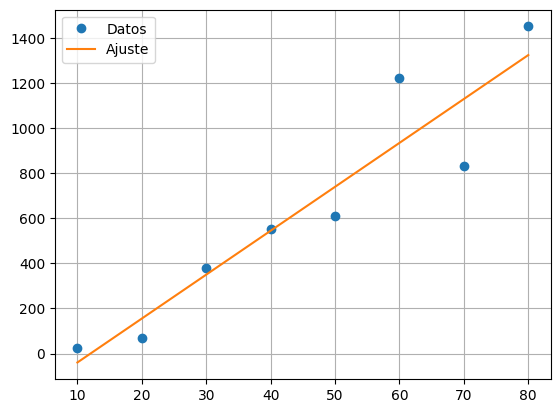

slope: 19.470238095238095
intersection: -234.28571428571422
r^2: 0.8804852467812263


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x=np.array([10,20,30,40,50,60,70,80])
y=np.array([25,70,380,550,610,1220,830,1450])

n=len(x)
if len(y) != n:
    raise ValueError("x and y must contain the same number of elements")

sx=np.sum(x)
sy=np.sum(y)
sx2=np.sum(x*x)
sxy=np.sum(x*y)
sy2=np.sum(y*y)

a1=(n*sxy - sx*sy) / (n*sx2-sx**2)
a2=sy/n - a1*sx/n

r2=((n*sxy-sx*sy)/ np.sqrt(n*sx2-sx**2)/np.sqrt(n*sy2-sy**2))**2

xp = np.linspace(np.min(x), np.max(x), 100)
yp=a1*xp+a2

plt.plot(x, y, 'o', label='Datos')
plt.plot(xp, yp, label='Ajuste')
plt.grid()
plt.legend()
plt.show()

print("slope:", a1)
print("intersection:", a2)
print("r^2:", r2)

Código 21. Ajuste de Datos en R**2 usando un modelo Potencia mediante linealización y regresión lineal

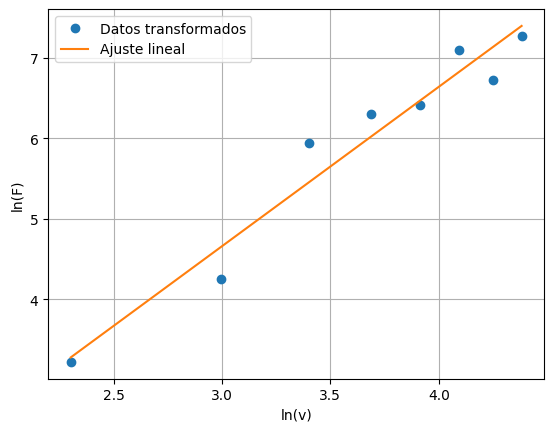

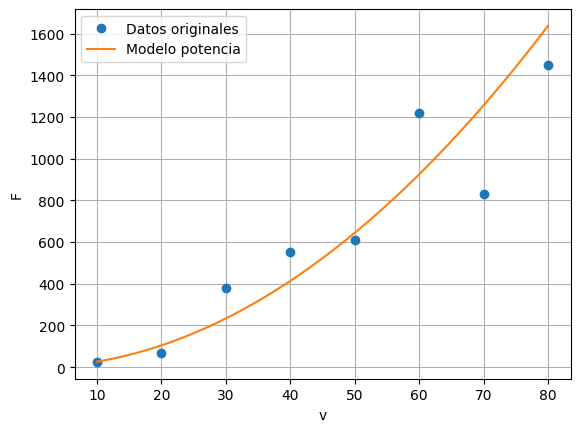

a = 0.2741373420132226
b = 1.9841762557640112
R^2 (log) = 0.9480533472023587
R^2 (original) = 0.8088181209722812


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
v=np.array([10,20,30,40,50,60,70,80])
F=np.array([25,70,380,550,610,1220,830,1450])
#pasamos a logaritmos
X=np.log(v)
Y=np.log(F)
#Hacemos el cálculo de las sumas
n = len(X)
sx = np.sum(X)
sy = np.sum(Y)
sx2 = np.sum(X * X)
sxy = np.sum(X * Y)
sy2 = np.sum(Y * Y)
#el ajuste lineal en el espacio de log
b = (n*sxy - sx*sy) / (n*sx2 - sx**2)
A = sy/n - b*sx/n   # esto es ln(a)
# 5. Recuperar parámetro a
a = np.exp(A)
# 6. R^2 en espacio transformado (log)
r2_log = ((n*sxy - sx*sy) / np.sqrt(n*sx2 - sx**2) / np.sqrt(n*sy2 - sy**2))**2
# 7. R^2 en espacio original
F_pred = a * v**b
SS_res = np.sum((F - F_pred)**2)
SS_tot = np.sum((F - np.mean(F))**2)
r2 = 1 - SS_res / SS_tot
# 8. Gráfica en espacio log-log
xp = np.linspace(np.min(X), np.max(X), 100)
yp = b*xp + A
plt.figure()
plt.plot(X, Y, 'o', label='Datos transformados')
plt.plot(xp, yp, label='Ajuste lineal')
plt.xlabel('ln(v)')
plt.ylabel('ln(F)')
plt.legend()
plt.grid()
# 9. Gráfica en espacio original
vp = np.linspace(np.min(v), np.max(v), 100)
Fp = a * vp**b
plt.figure()
plt.plot(v, F, 'o', label='Datos originales')
plt.plot(vp, Fp, label='Modelo potencia')
plt.xlabel('v')
plt.ylabel('F')
plt.legend()
plt.grid()
plt.show()
# 10. Resultados
print("a =", a)
print("b =", b)
print("R^2 (log) =", r2_log)
print("R^2 (original) =", r2)

Código 22. Interpolación con Polinomios de Newton, a ln(2) y a densidades de fluidos en función de la Temp.

In [ ]:
import numpy as np

# funcion newton
def newtint(x, y, xx):
    n = len(x)
   
    b = np.zeros((n,n))
    b[:,0] = y
   
    for j in range(1,n):
        for i in range(n-j):
            b[i,j] = (b[i+1,j-1]-b[i,j-1])/(x[i+j]-x[i])
   
    xt = 1.0
    yint = b[0,0]
   
    for j in range(n-1):
        xt *= (xx - x[j])
        yint += b[0,j+1]*xt
       
    return yint

# ln(2)
x_ln = np.array([1, 1.5, 2, 2.5])
y_ln = np.log(x_ln)

xx = 2
aprox_ln2 = newtint(x_ln, y_ln, xx)
real_ln2 = np.log(2)

error_rel = abs((real_ln2 - aprox_ln2)/real_ln2)

print("ln(2) aproximado =", aprox_ln2)
print("ln(2) real       =", real_ln2)
print("Error relativo   =", error_rel)
print()

# densidad a 350
T = np.array([-40, 0, 20, 50, 100, 150, 200, 250, 300, 400, 500])
rho = np.array([1.52, 1.29, 1.20, 1.09, 0.946, 0.835, 0.746, 0.675, 0.616, 0.525, 0.457])

T_eval = 350

rho_350 = newtint(T, rho, T_eval)

print("Densidad a 350°C =", rho_350, "kg/m^3")

ln(2) aproximado = 0.6931471805599453
ln(2) real       = 0.6931471805599453
Error relativo   = 0.0

Densidad a 350°C = 0.5449722376654179 kg/m^3


Código 23. Interpolación con Polinomios de Lagrange a ln(2). Comparar error relativo con polinomio de Newton

Grado   Newton Error        Lagrange Error
1       3.1517202917e-01     3.1517202917e-01
2       9.1247815804e-02     9.1247815804e-02
3       1.7698595228e-02     1.7698595228e-02
4       1.6382758182e-03     1.6382758182e-03
5       0.0000000000e+00     0.0000000000e+00


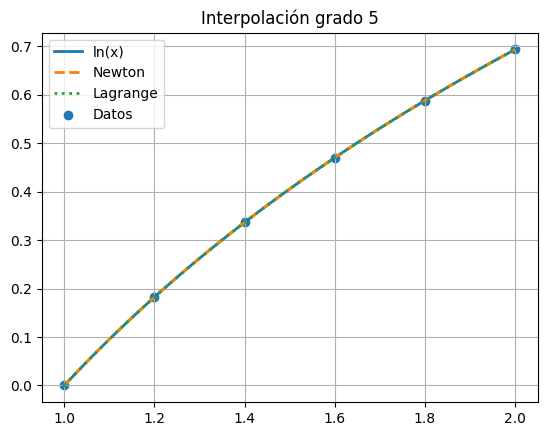

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# NEWTON

def newtint(x, y, xx):
    n = len(x)
    b = np.zeros((n,n))
    b[:,0] = y
   
    for j in range(1,n):
        for i in range(n-j):
            b[i,j] = (b[i+1,j-1]-b[i,j-1])/(x[i+j]-x[i])
   
    xt = 1.0
    yint = b[0,0]
   
    for j in range(n-1):
        xt *= (xx - x[j])
        yint += b[0,j+1]*xt
       
    return yint


# LAGRANGE

def lagrange(x, y, xx):
    n = len(x)
    s = 0
   
    for i in range(n):
        product = y[i]
        for j in range(n):
            if i != j:
                product *= (xx-x[j])/(x[i]-x[j])
        s += product
       
    return s


# DATOS

x_full = np.array([1, 1.2, 1.4, 1.6, 1.8, 2])
y_full = np.log(x_full)

xx = 2
real = np.log(2)


# TABLA

print("Grado   Newton Error        Lagrange Error")

for grado in range(1,6):
   
    x = x_full[:grado+1]
    y = y_full[:grado+1]
   
    yn = newtint(x,y,xx)
    yl = lagrange(x,y,xx)
   
    err_n = abs((real - yn)/real)
    err_l = abs((real - yl)/real)
   
    print(f"{grado}       {err_n:.10e}     {err_l:.10e}")

# GRAFICA

x = x_full[:6]
y = y_full[:6]

xx_plot = np.linspace(1,2,100)

yn_plot = [newtint(x,y,val) for val in xx_plot]
yl_plot = [lagrange(x,y,val) for val in xx_plot]

plt.plot(xx_plot, np.log(xx_plot), linewidth=2)
plt.plot(xx_plot, yn_plot, linestyle='--', linewidth=2)
plt.plot(xx_plot, yl_plot, linestyle=':', linewidth=2)
plt.scatter(x,y)

plt.legend(['ln(x)','Newton','Lagrange','Datos'])
plt.title('Interpolación grado 5')
plt.grid()
plt.show()

Código 24. Ajuste con spline a los datos de concentración de fosforo, Lago Ontario 1965 - 2012

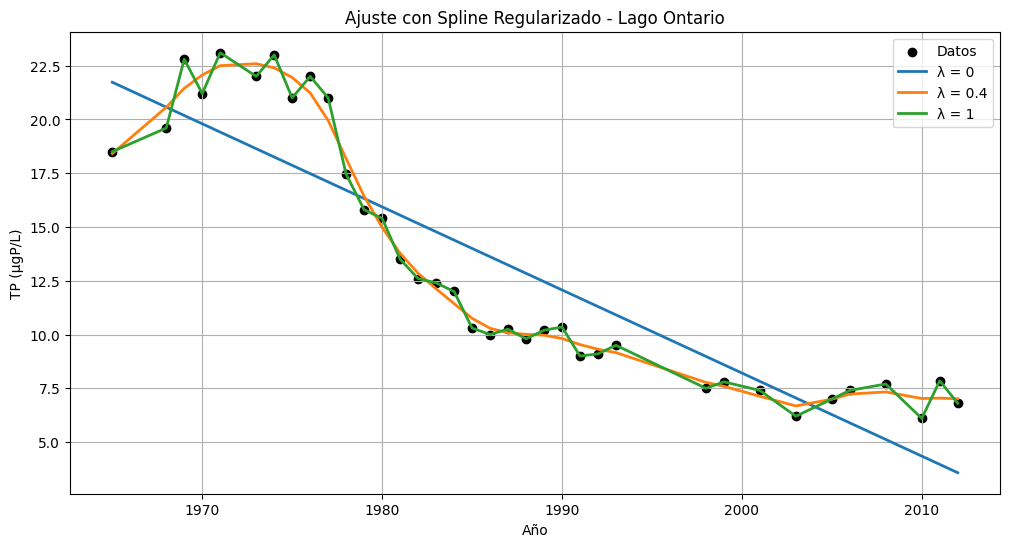

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def ysmooth(x, y, lam, sy=1):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if lam == 0:
        lam = 1e-8

    mu = 2 * (1 - lam) / (3 * lam)
    n = len(x)

    xd = np.diff(x)

    h = xd.copy()
    r = 3 / h

    p = np.zeros(n - 2)
    f = np.zeros(n - 2)

    for j in range(n - 2):
        p[j] = 2 * (h[j] + h[j + 1])
        f[j] = -(r[j] + r[j + 1])

    Rmat = np.zeros((n - 2, n - 2))

    for j in range(n - 3):
        Rmat[j, j] = p[j]
        Rmat[j + 1, j] = h[j + 1]
        Rmat[j, j + 1] = h[j + 1]

    Rmat[n - 3, n - 3] = p[n - 3]

    Qp = np.zeros((n - 2, n))

    for j in range(n - 3):
        Qp[j, j] = r[j]
        Qp[j, j + 1] = f[j]
        Qp[j, j + 2] = r[j + 1]

    Qp[n - 3, n - 3] = r[n - 3]
    Qp[n - 3, n - 2] = -(r[n - 3] + r[n - 2])
    Qp[n - 3, n - 1] = r[n - 2]

    Q = Qp.T

    SigMat = sy * np.eye(n)

    Qt = Qp @ SigMat
    Qcoef = Qt @ Q

    for i in range(n - 2):
        for j in range(n - 2):
            Qcoef[i, j] = mu * Qcoef[i, j] + Rmat[i, j]

    bvec = Qp @ y
    cvec = np.linalg.solve(Qcoef, bvec)

    ysmooth = y - mu * SigMat @ Q @ cvec

    return ysmooth


# DATOS LAGO ONTARIO
x = np.array([
    1965,1968,1969,1970,1971,1973,1974,1975,1976,
    1977,1978,1979,1980,1981,1982,1983,1984,1985,
    1986,1987,1988,1989,1990,1991,1992,1993,1998,
    1999,2001,2003,2005,2006,2008,2010,2011,2012
])

y = np.array([
    18.50,19.60,22.80,21.20,23.10,22.00,23.00,21.00,22.00,
    21.00,17.45,15.80,15.40,13.50,12.60,12.40,12.00,10.30,
    10.00,10.25,9.80,10.20,10.35,9.00,9.10,9.50,7.50,
    7.80,7.40,6.20,7.00,7.40,7.70,6.10,7.85,6.80
])


# GRAFICAR
plt.figure(figsize=(12,6))
plt.scatter(x, y, color='black', label='Datos')

for lam in [0, 0.4, 1]:
    ys = ysmooth(x, y, lam)
    plt.plot(x, ys, linewidth=2, label=f'λ = {lam}')

plt.title('Ajuste con Spline Regularizado - Lago Ontario')
plt.xlabel('Año')
plt.ylabel('TP (μgP/L)')
plt.legend()
plt.grid(True)
plt.show()

Código 25. Ajuste con splines a datos de profundidad y temperatura de un lago para encontrar la termoclina

Profundidad de termoclina: 11.3464 m
Temperatura en termoclina: 17.3113 °C


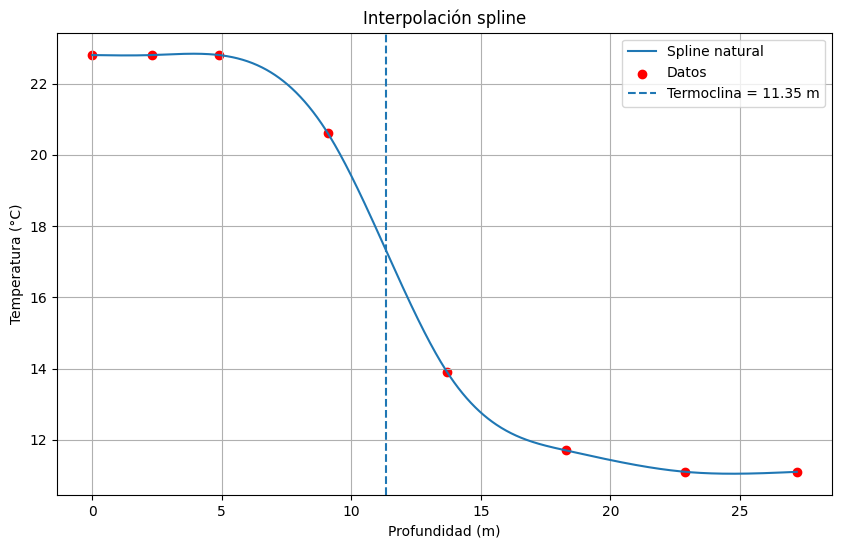

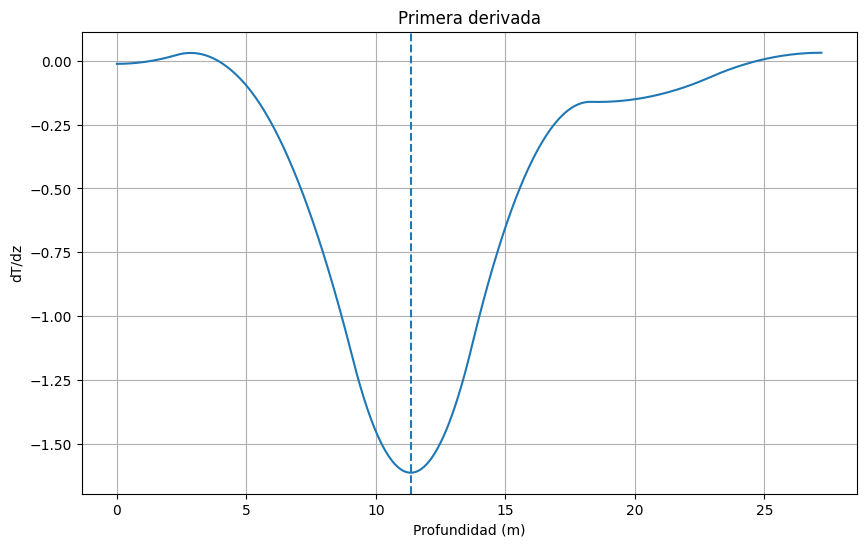

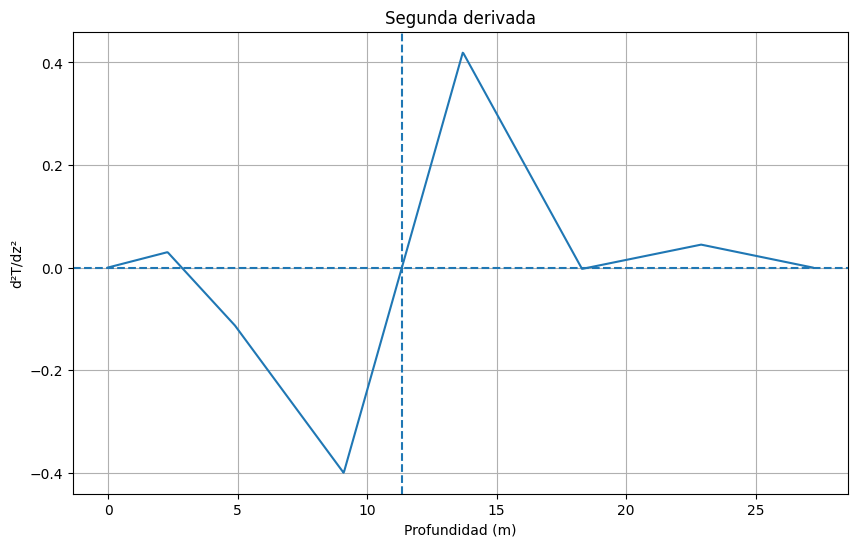

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import fsolve

z = np.array([0, 2.3, 4.9, 9.1, 13.7, 18.3, 22.9, 27.2])
T = np.array([22.8, 22.8, 22.8, 20.6, 13.9, 11.7, 11.1, 11.1])
cs = CubicSpline(z, T, bc_type='natural')

# malla fina
zz = np.linspace(min(z), max(z), 1000)

# interpolación
TT = cs(zz)

# derivadas
dT = cs(zz, 1)
d2T = cs(zz, 2)


# raiz 2da derivada
def second_derivative_root(x):
    return cs(x, 2)

# estimación inicial
z_therm = fsolve(second_derivative_root, 10)[0]

# temperatura ahí
T_therm = cs(z_therm)

print(f"Profundidad de termoclina: {z_therm:.4f} m")
print(f"Temperatura en termoclina: {T_therm:.4f} °C")


# graficas
plt.figure(figsize=(10,6))
plt.plot(zz, TT, label='Spline natural')
plt.scatter(z, T, color='red', label='Datos')
plt.axvline(z_therm, linestyle='--', label=f'Termoclina = {z_therm:.2f} m')
plt.xlabel('Profundidad (m)')
plt.ylabel('Temperatura (°C)')
plt.title('Interpolación spline')
plt.legend()
plt.grid(True)
plt.show()


# 1ra derivada
plt.figure(figsize=(10,6))
plt.plot(zz, dT)
plt.axvline(z_therm, linestyle='--')
plt.xlabel('Profundidad (m)')
plt.ylabel('dT/dz')
plt.title('Primera derivada')
plt.grid(True)
plt.show()


# 2dra derivada
plt.figure(figsize=(10,6))
plt.plot(zz, d2T)
plt.axhline(0, linestyle='--')
plt.axvline(z_therm, linestyle='--')
plt.xlabel('Profundidad (m)')
plt.ylabel('d²T/dz²')
plt.title('Segunda derivada')
plt.grid(True)
plt.show()

Código 26. Integración con regla trapezoidal compuesta

In [ ]:
import numpy as np

def f(x):
    return 0.2 + 25*x - 200*x**2 + 675*x**3 - 900*x**4 + 400*x**5
#regla
def trap(func, a, b, n):
    h = (b - a) / n

    suma = func(a) + func(b)

    for i in range(1, n):
        x = a + i*h
        suma += 2*func(x)

    return (h/2) * suma
# Datos
a = 0
b = 0.8
exacta = 1.640533


print(" n       h         I       Error (%)")
print("-"*40)

for n in range(2, 11):
    h = (b-a)/n
    I = trap(f, a, b, n)
    error = abs((exacta - I)/exacta)*100

    print(f"{n:2d}   {h:.4f}   {I:.4f}    {error:.1f}")

 n       h         I       Error (%)
----------------------------------------
 2   0.4000   1.0688    34.9
 3   0.2667   1.3696    16.5
 4   0.2000   1.4848    9.5
 5   0.1600   1.5399    6.1
 6   0.1333   1.5703    4.3
 7   0.1143   1.5887    3.2
 8   0.1000   1.6008    2.4
 9   0.0889   1.6091    1.9
10   0.0800   1.6150    1.6


Código 27. Integración método de Romberg-Richardson

In [ ]:
import numpy as np

def trap(func, a, b, n):
    h = (b - a) / n

    s = func(a) + func(b)

    for i in range(1, n):
        x = a + i * h
        s += 2 * func(x)

    I = (h / 2) * s
    return I

# romberg
def romberg(func, a, b, es=0.000001, maxit=50):

    I = np.zeros((maxit + 1, maxit + 1))

    n = 1
    I[0, 0] = trap(func, a, b, n)

    ea = 100
    iteration = 0

    while iteration < maxit:

        iteration += 1

        n = 2 ** iteration

        I[iteration, 0] = trap(func, a, b, n)
        for k in range(1, iteration + 1):

            j = iteration - k

            I[j, k] = (
                (4 ** k) * I[j + 1, k - 1] - I[j, k - 1]
            ) / (4 ** k - 1)
        ea = abs(
            (I[0, iteration] - I[1, iteration - 1])
            / I[0, iteration]
        ) * 100

        if ea <= es:
            break

    q = I[0, iteration]

    return q, ea, iteration

def f(x):
    return (
        0.2
        + 25 * x
        - 200 * x**2
        + 675 * x**3
        - 900 * x**4
        + 400 * x**5
    )

q, ea, it = romberg(f, 0, 0.8)

print(f"Integral = {q:.10f}")
print(f"Error aproximado = {ea:.10f} %")
print(f"Iteraciones = {it}")

Integral = 1.6405333333
Error aproximado = 0.0000000000 %
Iteraciones = 3


Método de Runge-Kutta de orden 4 para resolver un sistema de ecuaciones diferenciales

    t        x(t)        v(t)
--------------------------------
  0.00       0.0000       0.0000
  0.10       0.0490       0.9809
  0.20       0.1962       1.9611
  0.30       0.4412       2.9398
  0.40       0.7840       3.9165
  0.50       1.2244       4.8903
  0.60       1.7620       5.8607
  0.70       2.3964       6.8269
  0.80       3.1272       7.7883
  0.90       3.9539       8.7441
  1.00       4.8758       9.6939
  1.10       5.8924      10.6369
  1.20       7.0030      11.5726
  1.30       8.2067      12.5004
  1.40       9.5028      13.4197
  1.50      10.8903      14.3300
  1.60      12.3685      15.2308
  1.70      13.9362      16.1215
  1.80      15.5924      17.0018
  1.90      17.3362      17.8712
  2.00      19.1663      18.7292
  2.10      21.0816      19.5755
  2.20      23.0810      20.4097
  2.30      25.1632      21.2315
  2.40      27.3269      22.0407
  2.50      29.5708      22.8368
  2.60      31.8938      23.6197
  2.70      34.2943      24.3891
  2.80      3

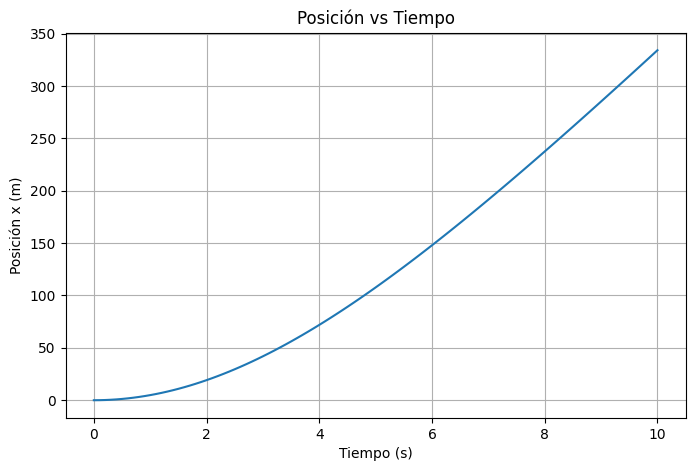

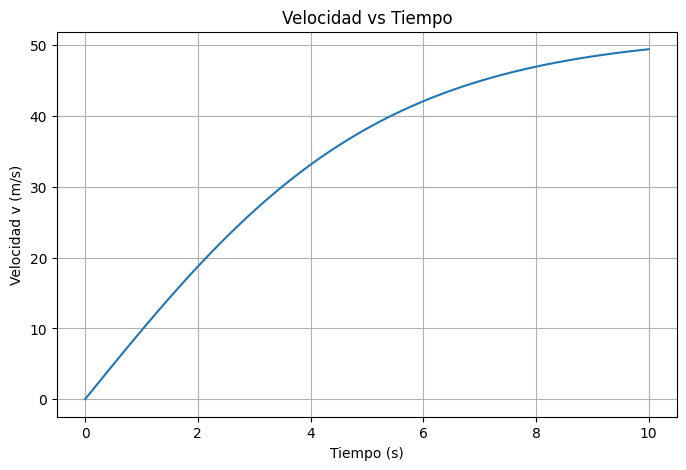

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# dx/dt = v, dv/dt = g - (cd/m)v^2

g = 9.81       
cd = 0.25      
m = 68.1       

def sistema(t, y):
    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = g - (cd/m)*(v**2)

    return np.array([dxdt, dvdt])

# rk4

def rk4(f, t0, tf, y0, h):

    t = np.arange(t0, tf + h, h)

    n = len(t)

    y = np.zeros((n, len(y0)))

    y[0] = y0

    for i in range(n - 1):

        k1 = f(t[i], y[i])

        k2 = f(t[i] + h/2, y[i] + h*k1/2)

        k3 = f(t[i] + h/2, y[i] + h*k2/2)

        k4 = f(t[i] + h, y[i] + h*k3)

        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return t, y

t0 = 0
tf = 10
h = 0.1

x0 = 0
v0 = 0

y0 = np.array([x0, v0])

#sol
t, y = rk4(sistema, t0, tf, y0, h)

x = y[:,0]
v = y[:,1]

print("    t        x(t)        v(t)")
print("--------------------------------")

for i in range(len(t)):
    print(f"{t[i]:6.2f}   {x[i]:10.4f}   {v[i]:10.4f}")

plt.figure(figsize=(8,5))
plt.plot(t, x)
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición x (m)")
plt.title("Posición vs Tiempo")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(t, v)
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad v (m/s)")
plt.title("Velocidad vs Tiempo")
plt.grid(True)
plt.show()

2 de Junio

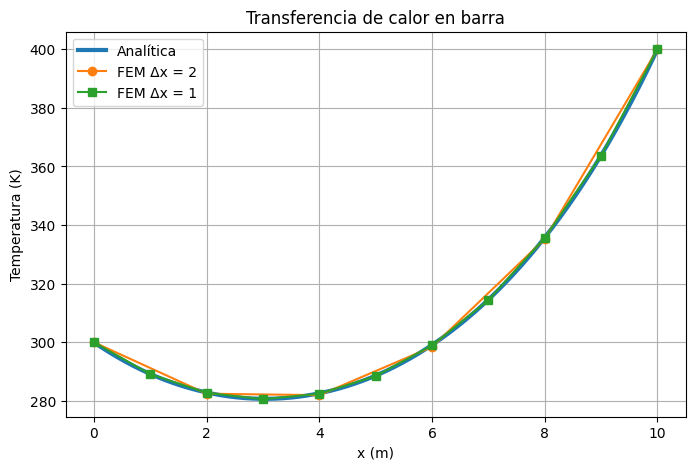


Temperaturas FEM Δx = 2
x =  0.0   T = 300.0000
x =  2.0   T = 282.4435
x =  4.0   T = 281.9442
x =  6.0   T = 298.3989
x =  8.0   T = 335.2120
x = 10.0   T = 400.0000

Temperaturas FEM Δx = 1
x =  0.0   T = 300.0000
x =  1.0   T = 289.1330
x =  2.0   T = 282.7601
x =  3.0   T = 280.5599
x =  4.0   T = 282.4217
x =  5.0   T = 288.4391
x =  6.0   T = 298.9156
x =  7.0   T = 314.3795
x =  8.0   T = 335.6104
x =  9.0   T = 363.6789
x = 10.0   T = 400.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 10.0
hp = 0.05
Tinf = 200.0

Ta = 300.0
Tb = 400.0

m = np.sqrt(hp)

A = np.array([
    [1, 1],
    [np.exp(m * L), np.exp(-m * L)]
])

b = np.array([
    Ta - Tinf,
    Tb - Tinf
])

C1, C2 = np.linalg.solve(A, b)

x_exact = np.linspace(0, L, 500)

T_exact = (
    Tinf
    + C1 * np.exp(m * x_exact)
    + C2 * np.exp(-m * x_exact)
)


def fem_heat(dx):

    nElem = int(L / dx)
    nNodes = nElem + 1

    K = np.zeros((nNodes, nNodes))
    F = np.zeros(nNodes)

    for e in range(nElem):

        ke = (1 / dx) * np.array([
            [1, -1],
            [-1, 1]
        ])

        re = hp * dx / 6 * np.array([
            [2, 1],
            [1, 2]
        ])

        fe = hp * Tinf * dx / 2 * np.array([
            1,
            1
        ])

        Ke = ke + re

        nodes = [e, e + 1]

        for i in range(2):
            for j in range(2):
                K[nodes[i], nodes[j]] += Ke[i, j]

            F[nodes[i]] += fe[i]

    K[0, :] = 0
    K[0, 0] = 1
    F[0] = Ta

    K[-1, :] = 0
    K[-1, -1] = 1
    F[-1] = Tb

    T = np.linalg.solve(K, F)

    x = np.linspace(0, L, nNodes)

    return x, T


x2, T2 = fem_heat(2)

x1, T1 = fem_heat(1)

plt.figure(figsize=(8, 5))

plt.plot(
    x_exact,
    T_exact,
    linewidth=3,
    label='Analítica'
)

plt.plot(
    x2,
    T2,
    'o-',
    label='FEM Δx = 2'
)

plt.plot(
    x1,
    T1,
    's-',
    label='FEM Δx = 1'
)

plt.xlabel('x (m)')
plt.ylabel('Temperatura (K)')
plt.title('Transferencia de calor en barra')
plt.grid(True)
plt.legend()

plt.show()

print("\nTemperaturas FEM Δx = 2")
for xi, Ti in zip(x2, T2):
    print(f"x = {xi:4.1f}   T = {Ti:8.4f}")

print("\nTemperaturas FEM Δx = 1")
for xi, Ti in zip(x1, T1):
    print(f"x = {xi:4.1f}   T = {Ti:8.4f}")